Data analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data shape: (28619, 3)
   is_sarcastic                                           headline  \
0             1  thirtysomething scientists unveil doomsday clo...   
1             0  dem rep. totally nails why congress is falling...   
2             0  eat your veggies: 9 deliciously different recipes   
3             1  inclement weather prevents liar from getting t...   
4             1  mother comes pretty close to using word 'strea...   

                                        article_link  
0  https://www.theonion.com/thirtysomething-scien...  
1  https://www.huffingtonpost.com/entry/donna-edw...  
2  https://www.huffingtonpost.com/entry/eat-your-...  
3  https://local.theonion.com/inclement-weather-p...  
4  https://www.theonion.com/mother-comes-pretty-c...  

Columns: ['is_sarcastic', 'headline', 'article_link']

Missing values:
 is_sarcastic    0
headline        0
article_link    0
dtype: int64

Label distribution:
label_name
Non-sarcastic    14985
Sarcastic        13634
Name: co

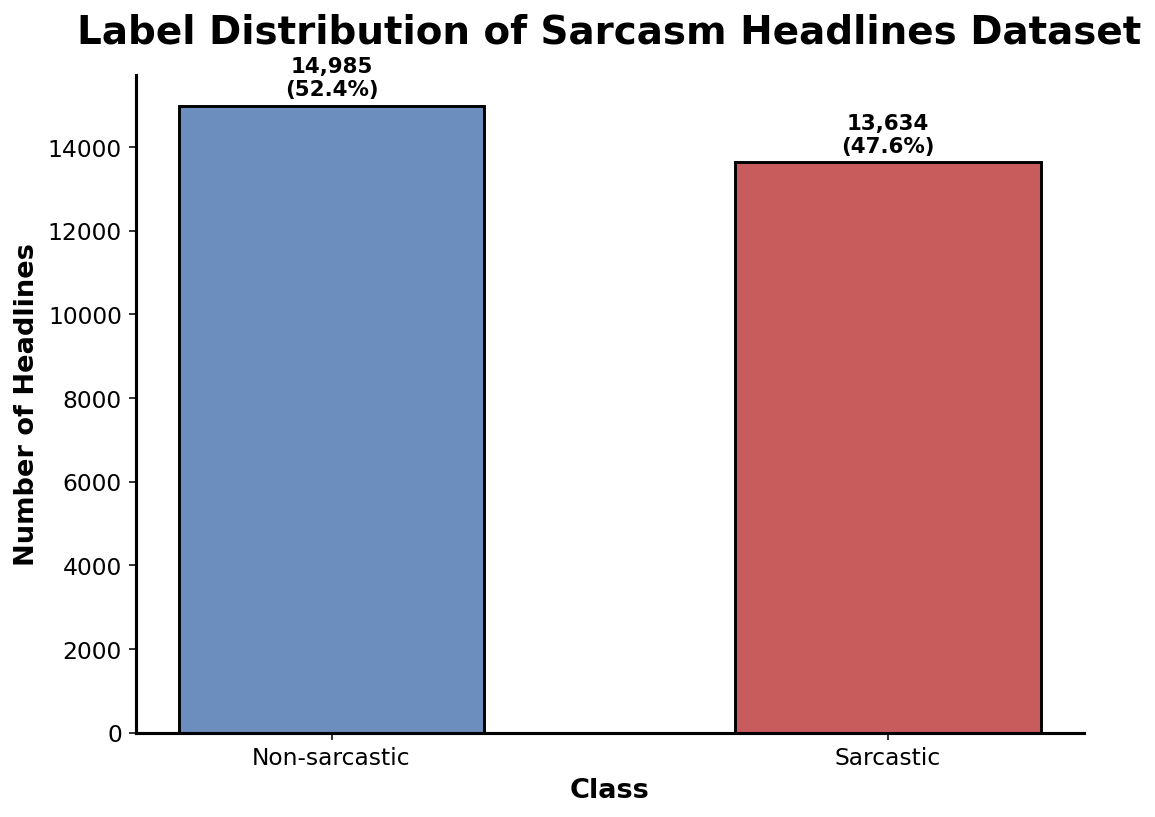

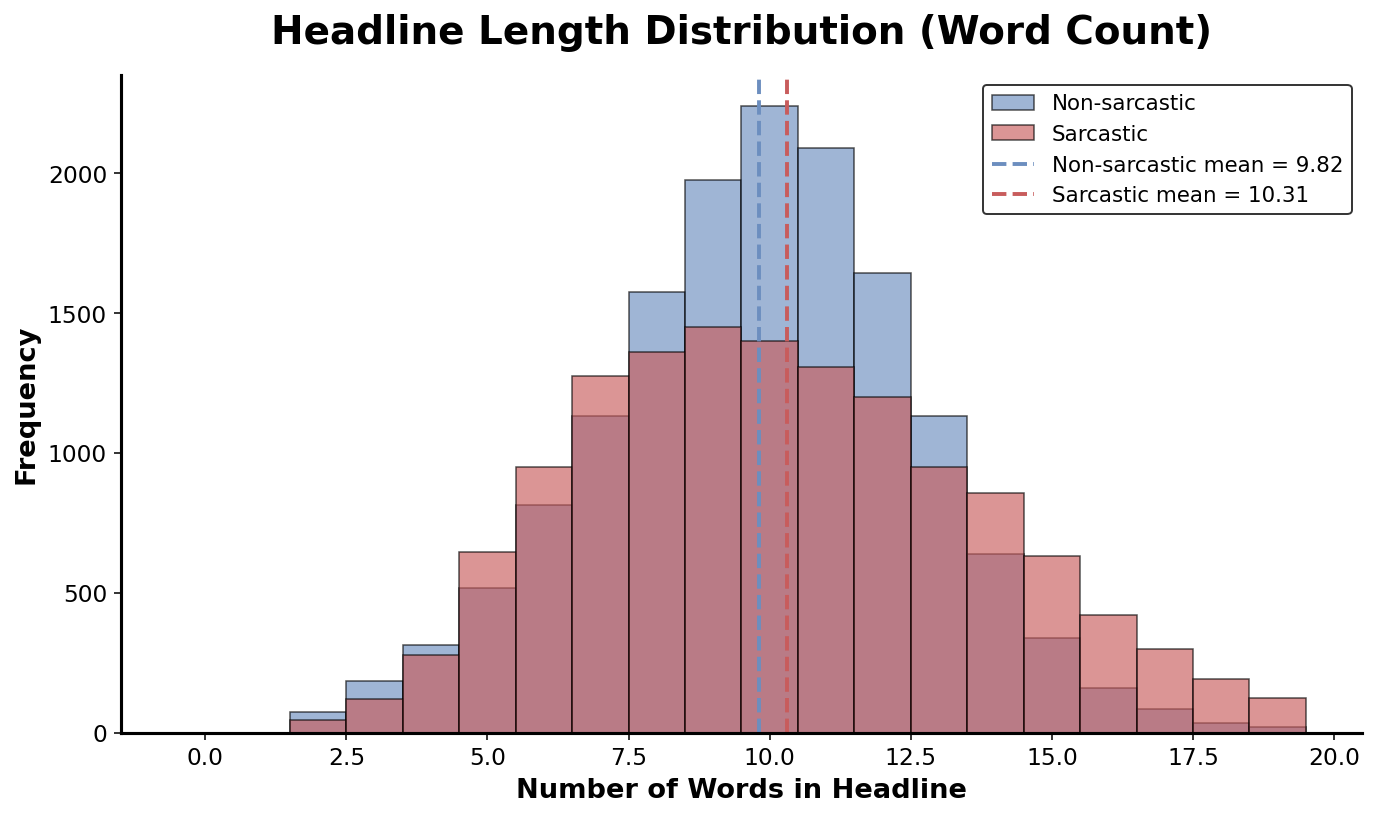

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 1. 读取 JSONL 数据
# =========================
file_path = Path("/content/Sarcasm_Headlines_Dataset_v2.json")
# 如果你的文件名不是这个，就改成自己的文件名
# 比如：Path("Sarcasm_Headlines_Dataset_v2.json")

records = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:  # 跳过空行
            records.append(json.loads(line))

df = pd.DataFrame(records)

print("Data shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())


# =========================
# 2. 构造 headline 长度特征
# =========================
df["headline"] = df["headline"].astype(str)

# 词数长度
df["headline_word_len"] = df["headline"].apply(lambda x: len(x.split()))

# 字符长度（包含空格）
df["headline_char_len"] = df["headline"].apply(len)

# 标签名称
label_map = {0: "Non-sarcastic", 1: "Sarcastic"}
df["label_name"] = df["is_sarcastic"].map(label_map)

print("\nLabel distribution:")
print(df["label_name"].value_counts())

print("\nHeadline word length summary:")
print(df.groupby("label_name")["headline_word_len"].describe())

print("\nHeadline char length summary:")
print(df.groupby("label_name")["headline_char_len"].describe())


# =========================
# 3. 图表风格设置（参考学术PPT风格）
# =========================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.6,
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 11,
    "figure.dpi": 140
})

COLOR_SARC = "#C85C5C"
COLOR_NON = "#6C8EBF"
COLOR_NEUTRAL = "#BFBFBF"


# =========================
# 4. 标签分布图
# =========================
label_counts = df["label_name"].value_counts().reindex(["Non-sarcastic", "Sarcastic"])

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    label_counts.index,
    label_counts.values,
    width=0.55,
    edgecolor="black",
    linewidth=1.5,
    color=[COLOR_NON, COLOR_SARC]
)

ax.set_title("Label Distribution of Sarcasm Headlines Dataset", pad=16)
ax.set_ylabel("Number of Headlines")
ax.set_xlabel("Class")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

total = label_counts.sum()
for bar in bars:
    h = bar.get_height()
    ratio = h / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + total * 0.005,
        f"{int(h):,}\n({ratio:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# =========================
# 5. headline 词数长度分布图
# =========================
fig, ax = plt.subplots(figsize=(10, 6))

max_len = int(df["headline_word_len"].quantile(0.99))

sarcastic_lens = df.loc[df["is_sarcastic"] == 1, "headline_word_len"]
non_sarcastic_lens = df.loc[df["is_sarcastic"] == 0, "headline_word_len"]

bins = np.arange(0, max_len + 2) - 0.5

ax.hist(
    non_sarcastic_lens[non_sarcastic_lens <= max_len],
    bins=bins,
    alpha=0.65,
    edgecolor="black",
    linewidth=0.8,
    label="Non-sarcastic",
    color=COLOR_NON
)

ax.hist(
    sarcastic_lens[sarcastic_lens <= max_len],
    bins=bins,
    alpha=0.65,
    edgecolor="black",
    linewidth=0.8,
    label="Sarcastic",
    color=COLOR_SARC
)

non_mean = non_sarcastic_lens.mean()
sar_mean = sarcastic_lens.mean()

ax.axvline(non_mean, linestyle="--", linewidth=2, color=COLOR_NON, label=f"Non-sarcastic mean = {non_mean:.2f}")
ax.axvline(sar_mean, linestyle="--", linewidth=2, color=COLOR_SARC, label=f"Sarcastic mean = {sar_mean:.2f}")

ax.set_title("Headline Length Distribution (Word Count)", pad=16)
ax.set_xlabel("Number of Words in Headline")
ax.set_ylabel("Frequency")
ax.legend(frameon=True, edgecolor="black")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Baseline Model: TF-IDF + Logistic Regression



In [2]:
import json
from pathlib import Path

import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)


# =========================
# 1. 读取 JSONL 数据
# =========================
def load_jsonl(file_path):
    records = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)


# =========================
# 2. 数据加载
# =========================
data_path = "/content/Sarcasm_Headlines_Dataset_v2.json"
df = load_jsonl(data_path)

print("Data shape:", df.shape)
print(df.head())

assert "headline" in df.columns
assert "is_sarcastic" in df.columns

df = df.dropna(subset=["headline", "is_sarcastic"]).copy()
df["headline"] = df["headline"].astype(str)
df["is_sarcastic"] = df["is_sarcastic"].astype(int)

X = df["headline"]
y = df["is_sarcastic"]


# =========================
# 3. 直接读取已划分好的 train / valid / test
# =========================
train_path = "/content/train.csv"
valid_path = "/content/val.csv"
test_path  = "/content/test.csv"

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
test_df  = pd.read_csv(test_path)

X_train = train_df["headline"]
y_train = train_df["label"]

X_valid = valid_df["headline"]
y_valid = valid_df["label"]

X_test = test_df["headline"]
y_test = test_df["label"]

print("\nLoaded split sizes:")
print(f"Train: {len(X_train)}")
print(f"Valid: {len(X_valid)}")
print(f"Test : {len(X_test)}")


# =========================
# 4. TF-IDF + Logistic Regression
# =========================
lr_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "clf",
        LogisticRegression(
            C=1.0,
            max_iter=2000,
            solver="liblinear",
            random_state=42
        )
    )
])


# =========================
# 5. 训练
# =========================
print("\nTraining Logistic Regression baseline...")
lr_pipeline.fit(X_train, y_train)


# =========================
# 6. validation 集评估
# =========================
y_valid_pred = lr_pipeline.predict(X_valid)
y_valid_prob = lr_pipeline.predict_proba(X_valid)[:, 1]

valid_acc = accuracy_score(y_valid, y_valid_pred)
valid_p, valid_r, valid_f1, _ = precision_recall_fscore_support(
    y_valid, y_valid_pred, average="binary"
)

print("\n========== Validation Results ==========")
print(f"Accuracy : {valid_acc:.4f}")
print(f"Precision: {valid_p:.4f}")
print(f"Recall   : {valid_r:.4f}")
print(f"F1-score : {valid_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, y_valid_pred, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_valid, y_valid_pred))


# =========================
# 7. test 集评估
# =========================
y_test_pred = lr_pipeline.predict(X_test)
y_test_prob = lr_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_p, test_r, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average="binary"
)

print("\n========== Test Results ==========")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_p:.4f}")
print(f"Recall   : {test_r:.4f}")
print(f"F1-score : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


# =========================
# 8. 保存模型
# =========================
save_dir = Path("lr_baseline_outputs")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "tfidf_logreg_pipeline.joblib"
joblib.dump(lr_pipeline, model_path)
print(f"\nSaved model to: {model_path}")


# =========================
# 9. 保存划分后的数据
# =========================
train_df = pd.DataFrame({
    "headline": X_train.values,
    "is_sarcastic": y_train.values
})
valid_df = pd.DataFrame({
    "headline": X_valid.values,
    "is_sarcastic": y_valid.values
})
test_df = pd.DataFrame({
    "headline": X_test.values,
    "is_sarcastic": y_test.values
})

train_df.to_csv(save_dir / "train_split.csv", index=False, encoding="utf-8-sig")
valid_df.to_csv(save_dir / "valid_split.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(save_dir / "test_split.csv", index=False, encoding="utf-8-sig")

print(f"Saved splits to: {save_dir}")


# =========================
# 10. 保存 test 预测结果
# =========================
test_results = pd.DataFrame({
    "headline": X_test.values,
    "gold_label": y_test.values,
    "pred_label": y_test_pred,
    "pred_prob_sarcastic": y_test_prob
})
test_results.to_csv(save_dir / "test_predictions.csv", index=False, encoding="utf-8-sig")

print(f"Saved test predictions to: {save_dir / 'test_predictions.csv'}")

Data shape: (28619, 3)
   is_sarcastic                                           headline  \
0             1  thirtysomething scientists unveil doomsday clo...   
1             0  dem rep. totally nails why congress is falling...   
2             0  eat your veggies: 9 deliciously different recipes   
3             1  inclement weather prevents liar from getting t...   
4             1  mother comes pretty close to using word 'strea...   

                                        article_link  
0  https://www.theonion.com/thirtysomething-scien...  
1  https://www.huffingtonpost.com/entry/donna-edw...  
2  https://www.huffingtonpost.com/entry/eat-your-...  
3  https://local.theonion.com/inclement-weather-p...  
4  https://www.theonion.com/mother-comes-pretty-c...  

Loaded split sizes:
Train: 22895
Valid: 2862
Test : 2862

Training Logistic Regression baseline...

========== Validation Results ==========
Accuracy : 0.8138
Precision: 0.8294
Recall   : 0.7667
F1-score : 0.7968

Classificat

Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score, silhouette_score
import pandas as pd
import numpy as np

# =========================
# 7. 从第一段已训练好的 pipeline 中取出 LR 分类器
# =========================
clf = lr_pipeline.named_steps["clf"]

# LR 的 decision score（基于第二段里已有的 X_test_tfidf）
test_scores = clf.decision_function(X_test_tfidf)


# =========================
# 8. 定义 Separation Ratio 函数
#    separation ratio = 类间中心距离 / 类内平均散布
# =========================
def separation_ratio_nd(X, y):
    """
    X: shape [n_samples, n_features]
    y: binary labels (0/1)
    """
    X = np.asarray(X)
    y = np.asarray(y)

    X0 = X[y == 0]
    X1 = X[y == 1]

    mu0 = X0.mean(axis=0)
    mu1 = X1.mean(axis=0)

    between = np.linalg.norm(mu0 - mu1)

    within0 = np.mean(np.linalg.norm(X0 - mu0, axis=1))
    within1 = np.mean(np.linalg.norm(X1 - mu1, axis=1))
    within = (within0 + within1) / 2.0

    if within == 0:
        return np.nan
    return between / within


def separation_ratio_1d(scores, y):
    """
    一维版本，用于 LR decision score 空间
    """
    scores = np.asarray(scores)
    y = np.asarray(y)

    s0 = scores[y == 0]
    s1 = scores[y == 1]

    mu0 = s0.mean()
    mu1 = s1.mean()

    between = abs(mu0 - mu1)

    within0 = np.mean(np.abs(s0 - mu0))
    within1 = np.mean(np.abs(s1 - mu1))
    within = (within0 + within1) / 2.0

    if within == 0:
        return np.nan
    return between / within


# =========================
# 9. 计算 Before / After 指标
# =========================

# -------- Before: PCA 2D 空间 --------
silhouette_before = silhouette_score(X_plot, y_test.values)
sep_ratio_before = separation_ratio_nd(X_plot, y_test.values)

# -------- After: LR decision space --------
test_scores_2d = test_scores.reshape(-1, 1)

silhouette_after = silhouette_score(test_scores_2d, y_test.values)
sep_ratio_after = separation_ratio_1d(test_scores, y_test.values)

# -------- AUC --------
test_auc = roc_auc_score(y_test.values, test_probs)


# =========================
# 10. 打印结果
# =========================
print("\n" + "=" * 50)
print("Before vs After Metrics")
print("=" * 50)

print(f"Before (PCA 2D)  - Silhouette Score : {silhouette_before:.4f}")
print(f"Before (PCA 2D)  - Separation Ratio : {sep_ratio_before:.4f}")

print(f"After  (LR score)- Silhouette Score : {silhouette_after:.4f}")
print(f"After  (LR score)- Separation Ratio : {sep_ratio_after:.4f}")

print(f"After  (LR prob) - ROC-AUC          : {test_auc:.4f}")


Before vs After Metrics
Before (PCA 2D)  - Silhouette Score : 0.0169
Before (PCA 2D)  - Separation Ratio : 0.6341
After  (LR score)- Silhouette Score : 0.2996
After  (LR score)- Separation Ratio : 2.0838
After  (LR prob) - ROC-AUC          : 0.8853


Result analysis

Explained variance ratio: [0.002866   0.00249789]
Total explained variance: 0.005363895122196824


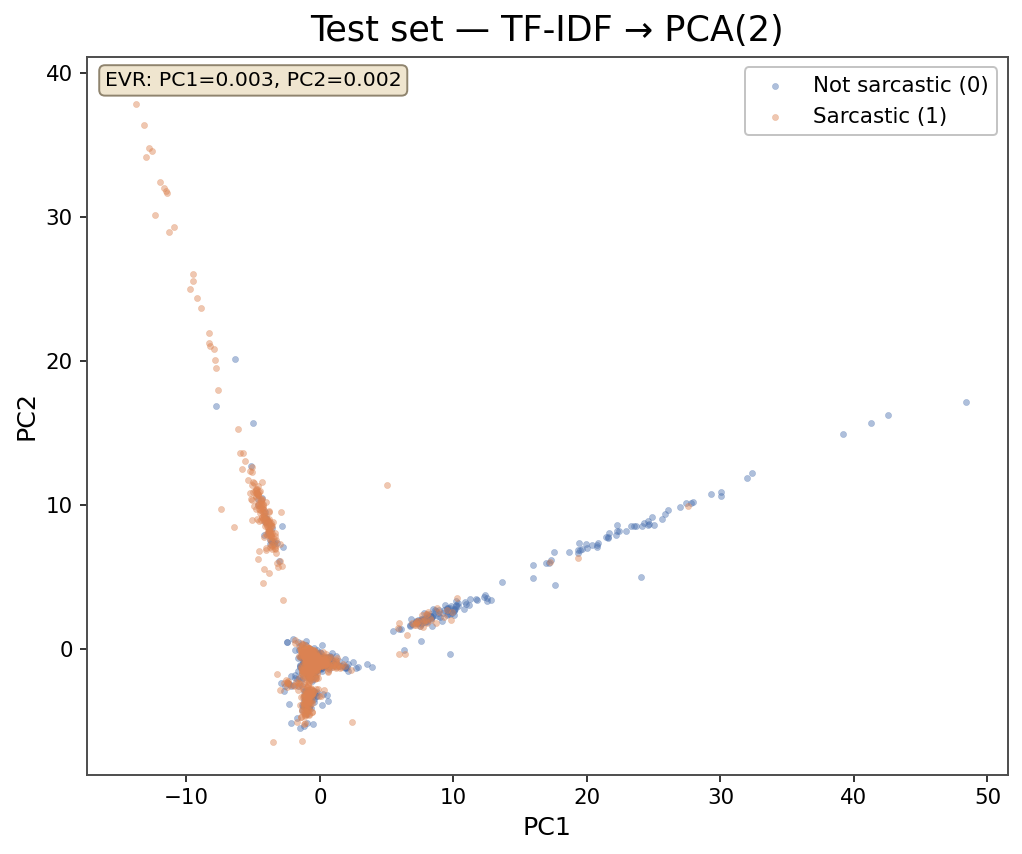

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

vectorizer = lr_pipeline.named_steps["tfidf"]

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
test_preds = y_test_pred
test_probs = y_test_prob


# =========================
# 2. PCA：只用 train 拟合，再投影 test
# =========================
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_tfidf.toarray())
X_test_2d = pca.transform(X_test_tfidf.toarray())

evr = pca.explained_variance_ratio_
print("Explained variance ratio:", evr)
print("Total explained variance:", evr.sum())


# =========================
# 3. 二维坐标标准化，便于显示
# =========================
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

display_scale = 3.8
X_plot = X_test_2d_scaled * display_scale


# =========================
# 4. 作图风格
# =========================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#4d4d4d",
    "axes.linewidth": 1.0,
    "axes.titlesize": 18,
    "axes.titleweight": "normal",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 140,
})

COLOR_NON = "#4C72B0"   # 蓝
COLOR_SARC = "#DD8452"  # 橙


# =========================
# 5. 图 1：Before training / 真实标签分布
# =========================
mask_non = (y_test.values == 0)
mask_sarc = (y_test.values == 1)

fig, ax = plt.subplots(figsize=(7.4, 6.2))

ax.scatter(
    X_plot[mask_non, 0],
    X_plot[mask_non, 1],
    s=10,
    alpha=0.45,
    c=COLOR_NON,
    edgecolors=COLOR_NON,
    linewidths=0.25,
    label="Not sarcastic (0)"
)

ax.scatter(
    X_plot[mask_sarc, 0],
    X_plot[mask_sarc, 1],
    s=10,
    alpha=0.45,
    c=COLOR_SARC,
    edgecolors=COLOR_SARC,
    linewidths=0.25,
    label="Sarcastic (1)"
)

ax.set_title("Test set — TF-IDF → PCA(2)", pad=8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

ax.text(
    0.02, 0.98,
    f"EVR: PC1={evr[0]:.3f}, PC2={evr[1]:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    bbox=dict(
        boxstyle="round,pad=0.28",
        facecolor="#efe5cf",
        edgecolor="#8f846e",
        linewidth=1.0
    )
)

ax.legend(
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="#c0c0c0"
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("#4d4d4d")

x_min, x_max = X_plot[:, 0].min(), X_plot[:, 0].max()
y_min, y_max = X_plot[:, 1].min(), X_plot[:, 1].max()
x_margin = 0.05 * (x_max - x_min)
y_margin = 0.05 * (y_max - y_min)

ax.set_xlim(x_min - x_margin, x_max + x_margin)
ax.set_ylim(y_min - y_margin, y_max + y_margin)

plt.tight_layout()
plt.show()

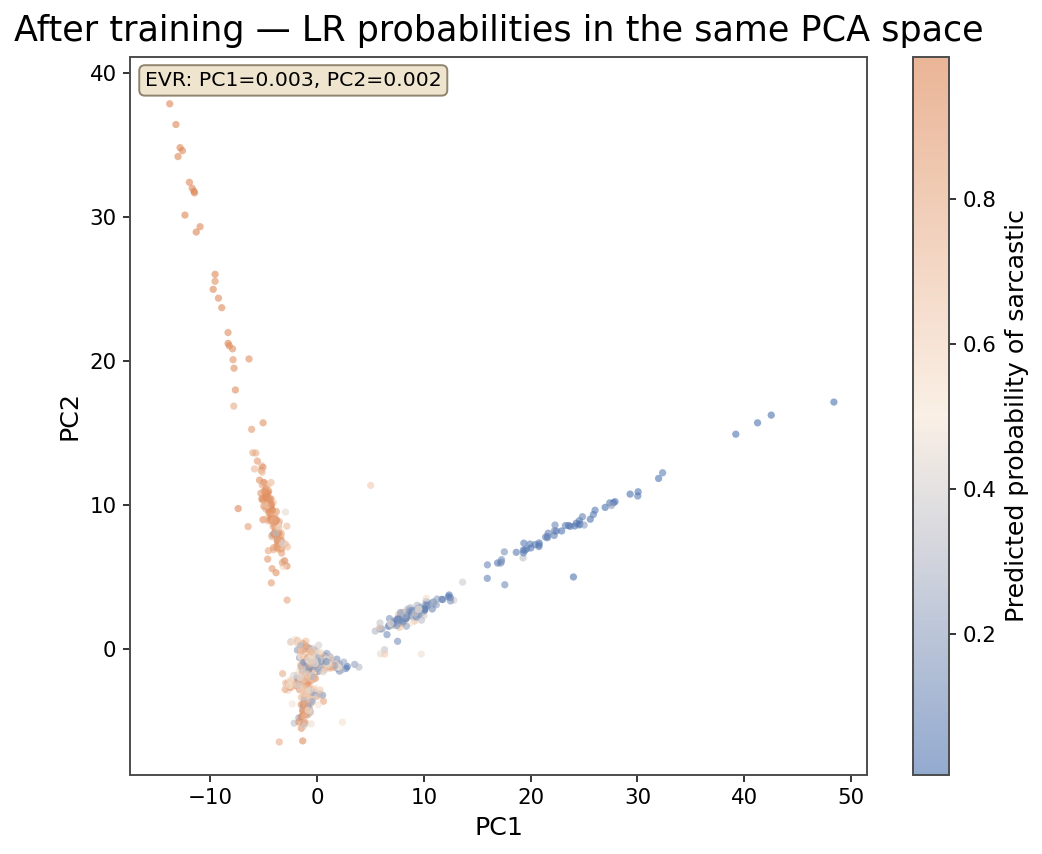

In [6]:
# =========================
# 图 2：After training
#      同一 PCA 空间，按高维 LR 预测概率着色
# =========================
fig, ax = plt.subplots(figsize=(7.4, 6.2))

from matplotlib.colors import LinearSegmentedColormap

blue_orange_cmap = LinearSegmentedColormap.from_list(
    "blue_orange",
    ["#4C72B0", "#F7E6D5", "#DD8452"]
)

sc = ax.scatter(
    X_plot[:, 0], X_plot[:, 1],
    c=test_probs,
    cmap=blue_orange_cmap,
    s=14,
    alpha=0.60,
    edgecolors="none"
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Predicted probability of sarcastic")

ax.set_title("After training — LR probabilities in the same PCA space", pad=8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

ax.text(
    0.02, 0.98,
    f"EVR: PC1={evr[0]:.3f}, PC2={evr[1]:.3f}",
    transform=ax.transAxes,
    ha="left", va="top", fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.28", facecolor="#efe5cf",
              edgecolor="#8f846e", linewidth=1.0)
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("#4d4d4d")

ax.set_xlim(x_min - x_margin, x_max + x_margin)
ax.set_ylim(y_min - y_margin, y_max + y_margin)

plt.tight_layout()
plt.show()

Error analysis

In [20]:
import json

# =========================
# 1. 读取两个错误文件
# =========================
lr_path = "lr_fp_fn_errors.json"
roberta_path = "roberta_fp_fn_errors.json"

with open(lr_path, "r", encoding="utf-8") as f:
    lr_errors = json.load(f)

with open(roberta_path, "r", encoding="utf-8") as f:
    roberta_errors = json.load(f)


# =========================
# 2. 辅助函数：把 list[dict] 转成 headline -> record
# =========================
def to_map(records):
    return {item["headline"]: item for item in records}


lr_fp_map = to_map(lr_errors["false_positives"])
lr_fn_map = to_map(lr_errors["false_negatives"])

roberta_fp_map = to_map(roberta_errors["false_positives"])
roberta_fn_map = to_map(roberta_errors["false_negatives"])


# =========================
# 3. 提取四组数据
# =========================
common_fp_headlines = sorted(set(lr_fp_map) & set(roberta_fp_map))
common_fn_headlines = sorted(set(lr_fn_map) & set(roberta_fn_map))

lr_only_fp_headlines = sorted(set(lr_fp_map) - set(roberta_fp_map))
lr_only_fn_headlines = sorted(set(lr_fn_map) - set(roberta_fn_map))

common_fp = [lr_fp_map[h] for h in common_fp_headlines]
common_fn = [lr_fn_map[h] for h in common_fn_headlines]
lr_only_fp = [lr_fp_map[h] for h in lr_only_fp_headlines]
lr_only_fn = [lr_fn_map[h] for h in lr_only_fn_headlines]


# =========================
# 4. 保存到一个 JSON 文件
# =========================
output = {
    "common_fp": common_fp,
    "common_fn": common_fn,
    "lr_only_fp": lr_only_fp,
    "lr_only_fn": lr_only_fn,
    "summary": {
        "common_fp_count": len(common_fp),
        "common_fn_count": len(common_fn),
        "lr_only_fp_count": len(lr_only_fp),
        "lr_only_fn_count": len(lr_only_fn),
    }
}

out_path = "lr_roberta_error_overlap.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Saved to: {out_path}")
print(json.dumps(output["summary"], ensure_ascii=False, indent=2))
print("\n" + "=" * 80)
print(f"COMMON FP ({len(common_fp)})")
print("=" * 80)
for i, item in enumerate(common_fp, 1):
    print(f"[common_fp {i}] {item['headline']}")

print("\n" + "=" * 80)
print(f"COMMON FN ({len(common_fn)})")
print("=" * 80)
for i, item in enumerate(common_fn, 1):
    print(f"[common_fn {i}] {item['headline']}")

print("\n" + "=" * 80)
print(f"LR-ONLY FP ({len(lr_only_fp)})")
print("=" * 80)
for i, item in enumerate(lr_only_fp, 1):
    print(f"[lr_only_fp {i}] {item['headline']}")

print("\n" + "=" * 80)
print(f"LR-ONLY FN ({len(lr_only_fn)})")
print("=" * 80)
for i, item in enumerate(lr_only_fn, 1):
    print(f"[lr_only_fn {i}] {item['headline']}")

Saved to: lr_roberta_error_overlap.json
{
  "common_fp_count": 35,
  "common_fn_count": 84,
  "lr_only_fp_count": 212,
  "lr_only_fn_count": 230
}

COMMON FP (35)
[common_fp 1] 'toni braxton: unbreak my heart' is lifetime's most watched movie in a year
[common_fp 2] astronomers discover most distant galaxy yet
[common_fp 3] cc sabathia opens up for first time since entering rehab
[common_fp 4] chief justice john roberts eulogizes antonin scalia as 'our man for all seasons'
[common_fp 5] church honors 'dearly beloved' prince by putting his lyrics on sign
[common_fp 6] commence to move forward
[common_fp 7] coroner's report finds no clear evidence of torture on otto warmbier's body
[common_fp 8] dick van dyke surprises denny's patrons with impromptu performance of 'chitty chitty bang bang'
[common_fp 9] dolphins chatter more when solving tricky tasks
[common_fp 10] family rewrites 'in da club' to celebrate back-to-school season
[common_fp 11] general mills releases tiny toast, its first 